In [94]:
# Imports
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import umap

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PLOTLY_TEMPLATE = "plotly_white"

ROOT = Path().resolve().parents[1] if "__file__" not in dir() else Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data" / "match_data"


In [95]:
# ── Champion Class Mapping ────────────────────────────────────────────────────

_RAW = {
    # Assassin
    "Akali": "Assassin", "Diana": "Assassin", "Ekko": "Assassin",
    "Evelynn": "Assassin", "Fizz": "Assassin", "Kassadin": "Assassin",
    "Katarina": "Assassin", "Kha'Zix": "Assassin", "Naafiri": "Assassin",
    "Nocturne": "Assassin", "Pyke": "Assassin", "Qiyana": "Assassin",
    "Rengar": "Assassin", "Shaco": "Assassin", "Talon": "Assassin",
    "Zed": "Assassin",

    # Skirmisher
    "Bel'Veth": "Skirmisher", "Fiora": "Skirmisher", "Gwen": "Skirmisher",
    "Jax": "Skirmisher", "Kayn": "Skirmisher", "Kled": "Skirmisher",
    "Lillia": "Skirmisher", "Master Yi": "Skirmisher", "Nilah": "Skirmisher",
    "Riven": "Skirmisher", "Tryndamere": "Skirmisher", "Viego": "Skirmisher",
    "Yasuo": "Skirmisher", "Yone": "Skirmisher", "Zaahen": "Skirmisher",

    # Juggernaut
    "Aatrox": "Juggernaut", "Darius": "Juggernaut", "Dr. Mundo": "Juggernaut",
    "Garen": "Juggernaut", "Illaoi": "Juggernaut", "Mordekaiser": "Juggernaut",
    "Nasus": "Juggernaut", "Sett": "Juggernaut", "Shyvana": "Juggernaut",
    "Trundle": "Juggernaut", "Udyr": "Juggernaut", "Urgot": "Juggernaut",
    "Volibear": "Juggernaut", "Yorick": "Juggernaut",

    # Diver
    "Ambessa": "Diver", "Briar": "Diver", "Camille": "Diver",
    "Elise": "Diver", "Hecarim": "Diver", "Irelia": "Diver",
    "Jarvan IV": "Diver", "Lee Sin": "Diver", "Olaf": "Diver",
    "Pantheon": "Diver", "Rek'Sai": "Diver", "Renekton": "Diver",
    "Skarner": "Diver", "Vi": "Diver", "Warwick": "Diver",
    "Wukong": "Diver", "Xin Zhao": "Diver",

    # Battlemage
    "Anivia": "Battlemage", "Aurelion Sol": "Battlemage", "Aurora": "Battlemage",
    "Cassiopeia": "Battlemage", "Karthus": "Battlemage", "Malzahar": "Battlemage",
    "Rumble": "Battlemage", "Ryze": "Battlemage", "Swain": "Battlemage",
    "Taliyah": "Battlemage", "Viktor": "Battlemage", "Vladimir": "Battlemage",

    # Burst
    "Ahri": "Burst", "Annie": "Burst", "Brand": "Burst",
    "Karma": "Burst", "LeBlanc": "Burst", "Lissandra": "Burst",
    "Neeko": "Burst", "Orianna": "Burst", "Seraphine": "Burst",
    "Sylas": "Burst", "Syndra": "Burst", "Twisted Fate": "Burst",
    "Veigar": "Burst", "Vex": "Burst", "Zoe": "Burst",

    # Artillery
    "Hwei": "Artillery", "Jayce": "Artillery", "Lux": "Artillery",
    "Mel": "Artillery", "Vel'Koz": "Artillery", "Xerath": "Artillery",
    "Ziggs": "Artillery",

    # Enchanter
    "Janna": "Enchanter", "Lulu": "Enchanter", "Milio": "Enchanter",
    "Nami": "Enchanter", "Renata Glasc": "Enchanter", "Sona": "Enchanter",
    "Soraka": "Enchanter", "Taric": "Enchanter", "Yuumi": "Enchanter",

    # Catcher
    "Bard": "Catcher", "Blitzcrank": "Catcher", "Ivern": "Catcher",
    "Morgana": "Catcher", "Rakan": "Catcher", "Thresh": "Catcher",
    "Zyra": "Catcher",

    # Vanguard
    "Alistar": "Vanguard", "Amumu": "Vanguard", "Gragas": "Vanguard",
    "Leona": "Vanguard", "Malphite": "Vanguard", "Maokai": "Vanguard",
    "Nautilus": "Vanguard", "Nunu & Willump": "Vanguard", "Nunu": "Vanguard",
    "Ornn": "Vanguard", "Rammus": "Vanguard", "Rell": "Vanguard",
    "Sejuani": "Vanguard", "Sion": "Vanguard", "Zac": "Vanguard",

    # Warden
    "Braum": "Warden", "Galio": "Warden", "K'Sante": "Warden",
    "Poppy": "Warden", "Shen": "Warden", "Tahm Kench": "Warden",

    # Marksman
    "Akshan": "Marksman", "Aphelios": "Marksman", "Ashe": "Marksman",
    "Caitlyn": "Marksman", "Corki": "Marksman", "Draven": "Marksman",
    "Ezreal": "Marksman", "Jhin": "Marksman", "Jinx": "Marksman",
    "Kai'Sa": "Marksman", "Kalista": "Marksman", "Kindred": "Marksman",
    "Kog'Maw": "Marksman", "Lucian": "Marksman", "Miss Fortune": "Marksman",
    "Samira": "Marksman", "Senna": "Marksman", "Sivir": "Marksman",
    "Smolder": "Marksman", "Tristana": "Marksman", "Twitch": "Marksman",
    "Varus": "Marksman", "Vayne": "Marksman", "Xayah": "Marksman",
    "Yunara": "Marksman", "Zeri": "Marksman",

    # Specialist
    "Azir": "Specialist", "Cho'Gath": "Specialist", "Fiddlesticks": "Specialist",
    "Gangplank": "Specialist", "Gnar": "Specialist", "Graves": "Specialist",
    "Heimerdinger": "Specialist", "Kayle": "Specialist", "Kennen": "Specialist",
    "Nidalee": "Specialist", "Quinn": "Specialist", "Singed": "Specialist",
    "Teemo": "Specialist", "Zilean": "Specialist",
}

import re
def _norm(s):
    return re.sub(r"[^a-z]", "", s.lower())

_CLASS_LOOKUP = {_norm(k): v for k, v in _RAW.items()}

def get_class(champion_name):
    return _CLASS_LOOKUP.get(_norm(str(champion_name)), "Unknown")

CLASS_ORDER = [
    "Assassin", "Skirmisher", "Juggernaut", "Diver",
    "Battlemage", "Burst", "Artillery",
    "Enchanter", "Catcher",
    "Vanguard", "Warden",
    "Marksman", "Specialist", "Unknown",
]

print(f"Champion class mapping loaded ({len(_RAW)} champions defined).")
print("Sample:", {c: get_class(c) for c in ["Jinx", "MissFortune", "LeeSin", "Thresh", "Aatrox", "Sylas"]})


Champion class mapping loaded (173 champions defined).
Sample: {'Jinx': 'Marksman', 'MissFortune': 'Marksman', 'LeeSin': 'Diver', 'Thresh': 'Catcher', 'Aatrox': 'Juggernaut', 'Sylas': 'Burst'}


In [96]:
# ── 1. Data Preparation ───────────────────────────────────────────────────────

# Load most recent CSV from match_data/
csv_files = sorted(DATA_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")
csv_path = csv_files[-1]
print(f"Loading: {csv_path}")
raw = pd.read_csv(csv_path)
print(f"Raw shape: {raw.shape}")

# Filter: drop remakes (champLevel < 3)
df = raw.dropna(subset=["win", "championName"]).copy()
df = df[df["champLevel"] >= 3]
df["win"] = df["win"].astype(int)

# ── Derived features ──────────────────────────────────────────────────────────
df["nonCsGold"]        = df["goldEarned"] - df["cs"] * 20   # gold from kills/objectives/assists
df["damageEfficiency"] = df["totalDamageToChampions"] / df["goldEarned"].replace(0, 1)
df["mitigationRatio"]  = df["damageSelfMitigated"] / (df["totalDamageTaken"] + df["damageSelfMitigated"]).replace(0, 1)

# Features used for logistic regression
FEATURES = [
    # Combat
    "kills", "deaths", "assists", "kda",
    "totalDamageToChampions", "totalDamageTaken", "damageSelfMitigated",
    "damageToBuildings", "damageToObjectives",
    # Economy
    "goldEarned", "cs", "neutralMinionsKilled",
    # Vision
    "visionScore", "wardsPlaced", "wardsKilled", "visionWardsBought",
    # CC / utility
    "timeCCingOthers", "totalTimeCCDealt",
    # Structures / objectives
    "turretKills",
    # Survival
    "champLevel", "totalTimeSpentDead", "longestTimeSpentLiving",
    # Derived
    "nonCsGold", "damageEfficiency", "mitigationRatio",
]
TARGET = "win"

df = df.dropna(subset=[TARGET] + FEATURES)

print(f"After filtering: {df.shape}")
print(f"Win rate: {df[TARGET].mean():.3f}")
print(f"Unique champions: {df['championName'].nunique()}")
print(f"Features: {len(FEATURES)}")


Loading: C:\Users\Laser\data\match_data\matches_2026-04-12_18-00-00.csv
Raw shape: (177395, 51)
After filtering: (176111, 54)
Win rate: 0.500
Unique champions: 172
Features: 25


In [97]:
# ── Feature Correlation Matrix ────────────────────────────────────────────────
# Pearson correlations between raw features across all games.
# Shows which stats move together — explains why some model coefficients
# are unstable and why PDP would be misleading for correlated pairs.

feat_corr = df[FEATURES].corr(method="pearson")

# Order features by hierarchical clustering for better visual grouping
_agg = AgglomerativeClustering(n_clusters=min(4, len(FEATURES)), linkage="ward")
_feat_cluster = _agg.fit_predict(feat_corr.values)
_feat_order = []
for cid in range(min(4, len(FEATURES))):
    _feat_order.extend(np.where(_feat_cluster == cid)[0])
feat_names_ordered = [FEATURES[i] for i in _feat_order]
corr_ordered = feat_corr.loc[feat_names_ordered, feat_names_ordered]

fig = go.Figure(go.Heatmap(
    z=corr_ordered.values,
    x=feat_names_ordered,
    y=feat_names_ordered,
    colorscale="RdBu_r",
    zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title="Pearson r", thickness=14),
    text=corr_ordered.round(2).values,
    texttemplate="%{text}",
    textfont=dict(size=8),
    hovertemplate="%{y} × %{x}: %{z:.3f}<extra></extra>",
))
fig.update_layout(
    title=dict(text="<b>Feature Correlation Matrix</b> (raw game data, Pearson r)", font_size=17),
    xaxis=dict(tickangle=-40, tickfont=dict(size=10)),
    yaxis=dict(autorange="reversed", tickfont=dict(size=10)),
    template=PLOTLY_TEMPLATE,
    height=1000,
    margin=dict(l=180, r=60, t=70, b=130),
)
fig.show()


In [98]:
# ── 2 & 3. Champion-Specific Logistic Regression ─────────────────────────────
# Train one logistic regression per champion.
# Features are standardized per-champion so coefficients are comparable.

MIN_SAMPLES = 400   # skip champions with fewer games than this

scaler_map = {}     # champion -> fitted StandardScaler
model_map  = {}     # champion -> fitted LogisticRegression
coef_map   = {}     # champion -> coefficient Series (index = feature names)
metrics_map = {}    # champion -> {"accuracy": ..., "auc": ...}

champion_groups = df.groupby("championName")

for champ, group in champion_groups:
    if len(group) < MIN_SAMPLES:
        continue

    X = group[FEATURES].values
    y = group[TARGET].values

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Fit logistic regression
    model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs")
    model.fit(X_scaled, y)

    # Store
    scaler_map[champ] = scaler
    model_map[champ]  = model
    coef_map[champ]   = pd.Series(model.coef_[0], index=FEATURES)

    y_pred      = model.predict(X_scaled)
    y_prob      = model.predict_proba(X_scaled)[:, 1]
    metrics_map[champ] = {
        "n_games":  len(group),
        "accuracy": accuracy_score(y, y_pred),
        "auc":      roc_auc_score(y, y_prob) if len(np.unique(y)) > 1 else np.nan,
    }

print(f"Trained models for {len(model_map)} champions (≥{MIN_SAMPLES} games).")
metrics_df = pd.DataFrame(metrics_map).T.sort_values("auc", ascending=False)
print(metrics_df.head(10).to_string())


Trained models for 150 champions (≥400 games).
          n_games  accuracy       auc
Belveth     999.0  0.933934  0.985199
Hecarim     841.0  0.916766  0.972874
Kindred     863.0  0.910776  0.971088
Nunu        639.0  0.898279  0.970722
Ivern       581.0  0.910499  0.970707
JarvanIV   1553.0  0.915003  0.969540
XinZhao     973.0  0.899281  0.967133
Yuumi       636.0  0.904088  0.966263
Graves     1537.0  0.898504  0.966171
Sivir      1151.0  0.905300  0.965147


In [99]:
# ── 4. Build Cross-Champion Coefficient Matrix ────────────────────────────────

coef_matrix = pd.DataFrame(coef_map).T   # shape: (num_champions, num_features)
coef_matrix = coef_matrix[FEATURES]      # enforce consistent column order
coef_matrix.dropna(how="any", inplace=True)

print(f"Coefficient matrix shape: {coef_matrix.shape}")
print(coef_matrix.describe().round(3).to_string())


Coefficient matrix shape: (150, 25)
         kills   deaths  assists      kda  totalDamageToChampions  totalDamageTaken  damageSelfMitigated  damageToBuildings  damageToObjectives  goldEarned       cs  neutralMinionsKilled  visionScore  wardsPlaced  wardsKilled  visionWardsBought  timeCCingOthers  totalTimeCCDealt  turretKills  champLevel  totalTimeSpentDead  longestTimeSpentLiving  nonCsGold  damageEfficiency  mitigationRatio
count  150.000  150.000  150.000  150.000                 150.000           150.000              150.000            150.000             150.000     150.000  150.000               150.000      150.000      150.000      150.000            150.000          150.000           150.000      150.000     150.000             150.000                 150.000    150.000           150.000          150.000
mean     0.014   -1.033    0.850    2.091                   0.881            -0.717                0.601              0.346               0.820      -0.236   -0.531          

In [100]:
# ── Champion Class Metadata ────────────────────────────────────────────────────
# SUPPORT_CLASSES is kept for visual annotation only (diamond markers in UMAP).
# All champions are clustered together — stratifying by Riot's class labels
# would impose prior knowledge and defeat the purpose of unsupervised discovery.
# If supports end up in their own cluster, that's a data-driven finding.

SUPPORT_CLASSES  = {"Enchanter", "Catcher", "Vanguard", "Warden"}
coef_matrix_full = coef_matrix.copy()   # alias kept for any downstream compat

print(f"Clustering all {len(coef_matrix)} champions together.")
print(f"SUPPORT_CLASSES kept for visual annotation only: {sorted(SUPPORT_CLASSES)}")


Clustering all 150 champions together.
SUPPORT_CLASSES kept for visual annotation only: ['Catcher', 'Enchanter', 'Vanguard', 'Warden']


Backward elimination...
  drop 'kda                       ' → 24 features  avg_sil=0.1029  diag_k=4
  drop 'totalTimeSpentDead        ' → 23 features  avg_sil=0.1115  diag_k=4
  drop 'damageToObjectives        ' → 22 features  avg_sil=0.1153  diag_k=4
  drop 'neutralMinionsKilled      ' → 21 features  avg_sil=0.1219  diag_k=4
  drop 'visionScore               ' → 20 features  avg_sil=0.1265  diag_k=3
  drop 'kills                     ' → 19 features  avg_sil=0.1298  diag_k=4
  drop 'damageToBuildings         ' → 18 features  avg_sil=0.1349  diag_k=3
  drop 'cs                        ' → 17 features  avg_sil=0.1414  diag_k=4
  drop 'timeCCingOthers           ' → 16 features  avg_sil=0.1481  diag_k=3
  drop 'deaths                    ' → 15 features  avg_sil=0.1557  diag_k=3
  drop 'assists                   ' → 14 features  avg_sil=0.1611  diag_k=3
  drop 'longestTimeSpentLiving    ' → 13 features  avg_sil=0.1666  diag_k=3
  drop 'wardsKilled               ' → 12 features  avg_sil=0.172

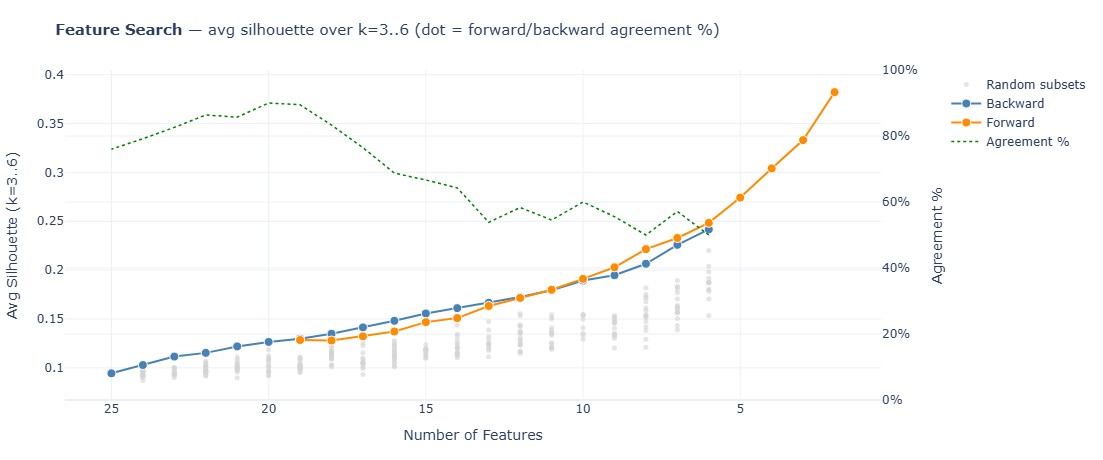


CHOSEN_N=6:
  Backward kept: ['damageEfficiency', 'goldEarned', 'totalDamageTaken', 'totalDamageToChampions', 'visionWardsBought', 'wardsPlaced']
  Forward kept:  ['cs', 'damageEfficiency', 'neutralMinionsKilled', 'timeCCingOthers', 'totalDamageToChampions', 'visionWardsBought']
  Agreed (3):    ['damageEfficiency', 'totalDamageToChampions', 'visionWardsBought']

CLUSTER_FEATURES = ['damageEfficiency', 'goldEarned', 'totalDamageTaken', 'totalDamageToChampions', 'visionWardsBought', 'wardsPlaced']
Set CHOSEN_N to override. Run GA cell next, then set CHOSEN_K in clustering cell.


In [101]:
# ── Feature Search — Forward, Backward + Random Search ───────────────────────
# Backward: start with all features, drop the least-useful one each step
# Forward:  start empty, add the most-useful one each step
# Random:   try N_RANDOM random subsets of varying sizes
#
# Scoring: average silhouette across k=3..6.
#   Skipping k=2 prevents feature selection from just optimizing the tank/non-tank
#   binary split. Features are chosen for multi-cluster discriminability.
#
# k selection is a separate decision made after features are locked in (see
# the clustering cell, which plots elbow + silhouette for k=2..6 and exposes
# a CHOSEN_K override).

MIN_FEATURES = 6
K_EVAL       = range(3, 7)   # k values used to score feature subsets (NOT used to pick final k)
N_RANDOM     = 300

np.random.seed(RANDOM_STATE)

def _best_sil(X):
    """Score a feature subset: average silhouette over K_EVAL.
    Returns (avg_sil, best_k_in_range) — avg_sil drives feature selection,
    best_k is shown for diagnostics only."""
    scores = {}
    for k in K_EVAL:
        if k >= X.shape[0]:
            break
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
        scores[k] = silhouette_score(X, labels)
    if not scores:
        return -1.0, 3
    return float(np.mean(list(scores.values()))), max(scores, key=scores.get)

# ── Backward ──────────────────────────────────────────────────────────────────
print("Backward elimination...")
remaining = list(FEATURES)
history_b = []
s0, k0 = _best_sil(coef_matrix[remaining].values)
history_b.append((len(remaining), s0, k0, None))
while len(remaining) > MIN_FEATURES:
    best_s, best_drop, best_k = -1, None, 3
    for feat in remaining:
        candidate = [f for f in remaining if f != feat]
        s_c, k_c = _best_sil(coef_matrix[candidate].values)
        if s_c > best_s:
            best_s, best_drop, best_k = s_c, feat, k_c
    remaining = [f for f in remaining if f != best_drop]
    history_b.append((len(remaining), best_s, best_k, best_drop))
    print(f"  drop '{best_drop:<26s}' → {len(remaining):2d} features  avg_sil={best_s:.4f}  diag_k={best_k}")
backward_df = pd.DataFrame(history_b, columns=["n_features", "silhouette", "best_k", "dropped"])

# ── Forward ───────────────────────────────────────────────────────────────────
print("\nForward selection...")
history_f = []

top_feats = coef_matrix[FEATURES].std().sort_values(ascending=False).head(10).index.tolist()
best_s2, best_pair = -1, top_feats[:2]
for i in range(len(top_feats)):
    for j in range(i + 1, len(top_feats)):
        pair = [top_feats[i], top_feats[j]]
        s_c, k_c = _best_sil(coef_matrix[pair].values)
        if s_c > best_s2:
            best_s2, best_pair = s_c, pair

added     = list(best_pair)
available = [f for f in FEATURES if f not in added]
history_f.append((2, best_s2, 2, f"{best_pair[0]} + {best_pair[1]}"))
print(f"  seed  '{best_pair[0]} + {best_pair[1]}'  → 2 features  avg_sil={best_s2:.4f}")

while len(added) < len(FEATURES) - MIN_FEATURES and available:
    best_s, best_add, best_k = -1, None, 3
    for feat in available:
        candidate = added + [feat]
        s_c, k_c = _best_sil(coef_matrix[candidate].values)
        if s_c > best_s:
            best_s, best_add, best_k = s_c, feat, k_c
    if best_add is None:
        break
    added.append(best_add)
    available.remove(best_add)
    history_f.append((len(added), best_s, best_k, best_add))
    print(f"  add  '{best_add:<26s}' → {len(added):2d} features  avg_sil={best_s:.4f}  diag_k={best_k}")
forward_df = pd.DataFrame(history_f, columns=["n_features", "silhouette", "best_k", "added"])

# ── Random search ─────────────────────────────────────────────────────────────
print(f"\nRandom search ({N_RANDOM} subsets)...")
random_rows = []
for _ in range(N_RANDOM):
    n = np.random.randint(MIN_FEATURES, len(FEATURES) + 1)
    subset = list(np.random.choice(FEATURES, size=n, replace=False))
    s_c, k_c = _best_sil(coef_matrix[subset].values)
    random_rows.append((n, s_c, k_c))
random_df = pd.DataFrame(random_rows, columns=["n_features", "silhouette", "best_k"])

# ── Agreement analysis ────────────────────────────────────────────────────────
def _backward_kept(n):
    kept = list(FEATURES)
    for _, row in backward_df.iterrows():
        if len(kept) <= n: break
        if row["dropped"] is not None:
            kept.remove(row["dropped"])
    return set(kept)

def _forward_kept(n):
    rows = forward_df[forward_df["n_features"] <= n]
    feats = []
    for a in rows["added"]:
        if " + " in str(a):
            feats.extend(a.split(" + "))
        else:
            feats.append(a)
    return set(feats)

print("\nForward / Backward agreement:")
agreement_rows = []
for n in range(MIN_FEATURES, len(FEATURES) + 1):
    b = _backward_kept(n)
    f = _forward_kept(n)
    inter = b & f
    agreement_rows.append({"n": n, "agree": len(inter), "pct": len(inter) / max(n, 1),
                            "features": sorted(inter)})
    if n in [6, 8, 10, 12, 15]:
        print(f"  n={n:2d}: {len(inter)}/{n} agree ({len(inter)/n*100:.0f}%) → {sorted(inter)}")
agreement_df = pd.DataFrame(agreement_rows)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=random_df["n_features"], y=random_df["silhouette"],
    mode="markers",
    marker=dict(color="lightgrey", size=5, opacity=0.6),
    name="Random subsets",
    hovertemplate="Random: %{x} features, avg_sil=%{y:.4f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=backward_df["n_features"], y=backward_df["silhouette"],
    mode="lines+markers",
    marker=dict(size=9, line=dict(width=1, color="white")),
    line=dict(color="steelblue", width=2),
    name="Backward",
    text=[f"drop: {d or '—'}<br>diag_k={k}" for d, k in zip(backward_df["dropped"], backward_df["best_k"])],
    hovertemplate="<b>Backward %{x} feat</b><br>avg_sil=%{y:.4f}<br>%{text}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=forward_df["n_features"], y=forward_df["silhouette"],
    mode="lines+markers",
    marker=dict(size=9, line=dict(width=1, color="white")),
    line=dict(color="darkorange", width=2),
    name="Forward",
    text=[f"add: {a}<br>diag_k={k}" for a, k in zip(forward_df["added"], forward_df["best_k"])],
    hovertemplate="<b>Forward %{x} feat</b><br>avg_sil=%{y:.4f}<br>%{text}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=agreement_df["n"], y=agreement_df["pct"],
    mode="lines",
    line=dict(color="green", width=1.5, dash="dot"),
    name="Agreement %",
    yaxis="y2",
    hovertemplate="n=%{x}: %{y:.0%} agreement<extra></extra>",
))

fig.update_layout(
    title=dict(
        text="<b>Feature Search</b> — avg silhouette over k=3..6 (dot = forward/backward agreement %)",
        font_size=15,
    ),
    xaxis=dict(title="Number of Features", autorange="reversed"),
    yaxis=dict(title="Avg Silhouette (k=3..6)"),
    yaxis2=dict(title="Agreement %", overlaying="y", side="right",
                tickformat=".0%", range=[0, 1]),
    template=PLOTLY_TEMPLATE,
    height=460,
    margin=dict(l=60, r=80, t=70, b=60),
    legend=dict(x=1.08, y=1),
)
fig.show()

# ── Select feature set ────────────────────────────────────────────────────────
# Peak of backward avg-silhouette curve → least features that still give good
# multi-k separability. Forward/backward intersection = most trustworthy features.
CHOSEN_N = None   # set an integer to override; None = auto (backward peak)

chosen_n = CHOSEN_N if CHOSEN_N is not None else int(backward_df.loc[backward_df["silhouette"].idxmax(), "n_features"])

b_kept = _backward_kept(chosen_n)
f_kept = _forward_kept(chosen_n)
agreed = b_kept & f_kept
CLUSTER_FEATURES = sorted(agreed) if len(agreed) >= MIN_FEATURES else sorted(b_kept)

print(f"\nCHOSEN_N={chosen_n}:")
print(f"  Backward kept: {sorted(b_kept)}")
print(f"  Forward kept:  {sorted(f_kept)}")
print(f"  Agreed ({len(agreed)}):    {sorted(agreed)}")
print(f"\nCLUSTER_FEATURES = {CLUSTER_FEATURES}")
print(f"Set CHOSEN_N to override. Run GA cell next, then set CHOSEN_K in clustering cell.")


Evolving 50 individuals × 25 generations...
  Gen  1: best=0.2484  mean=0.1530  n_feat=6
  Gen  2: best=0.2484  mean=0.1578  n_feat=6
  Gen  3: best=0.2484  mean=0.1599  n_feat=6
  Gen  4: best=0.2484  mean=0.1679  n_feat=6
  Gen  5: best=0.2582  mean=0.1616  n_feat=5
  Gen  6: best=0.2582  mean=0.1714  n_feat=5
  Gen  7: best=0.2680  mean=0.1800  n_feat=4
  Gen  8: best=0.2680  mean=0.1775  n_feat=4
  Gen  9: best=0.2680  mean=0.1770  n_feat=4
  Gen 10: best=0.3041  mean=0.1780  n_feat=4
  Gen 11: best=0.3041  mean=0.1821  n_feat=4
  Gen 12: best=0.3041  mean=0.1857  n_feat=4
  Gen 13: best=0.3041  mean=0.1872  n_feat=4
  Gen 14: best=0.3041  mean=0.1797  n_feat=4
  Gen 15: best=0.3041  mean=0.1817  n_feat=4
  Gen 16: best=0.3041  mean=0.1862  n_feat=4
  Gen 17: best=0.3041  mean=0.1868  n_feat=4
  Gen 18: best=0.3041  mean=0.1879  n_feat=4
  Gen 19: best=0.3041  mean=0.1846  n_feat=4
  Gen 20: best=0.3041  mean=0.1846  n_feat=4
  Gen 21: best=0.3041  mean=0.1859  n_feat=4
  Gen 22: b

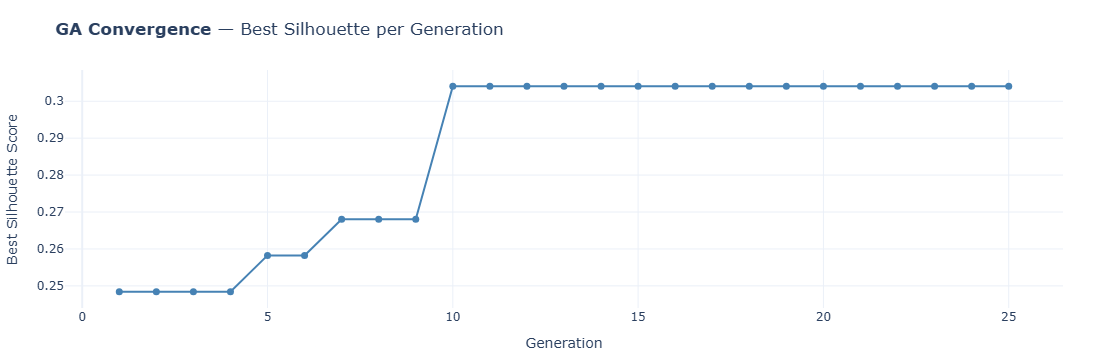

In [102]:
# ── Genetic Algorithm Feature Selection ───────────────────────────────────────
# Evolves a population of feature subsets toward higher silhouette scores.
# Escapes local optima that greedy forward/backward selection gets stuck in.
# Requires the feature search cell above to have been run first (_best_sil).

POP_SIZE      = 50
N_GENERATIONS = 25
MUTATION_RATE = 0.08
MIN_FEAT_GA   = 4

np.random.seed(RANDOM_STATE)

def _ga_fitness(ind):
    feats = [FEATURES[i] for i, b in enumerate(ind) if b]
    if len(feats) < 2:
        return -1.0
    s, _ = _best_sil(coef_matrix[feats].values)
    return s

def _crossover(p1, p2):
    pt = np.random.randint(1, len(FEATURES))
    return np.concatenate([p1[:pt], p2[pt:]])

def _mutate(ind):
    ind = ind.copy()
    flip = np.random.random(len(ind)) < MUTATION_RATE
    ind[flip] = 1 - ind[flip]
    while ind.sum() < MIN_FEAT_GA:
        ind[np.random.randint(len(ind))] = 1
    return ind

def _rand_individual():
    while True:
        ind = np.random.binomial(1, 0.5, len(FEATURES)).astype(int)
        if ind.sum() >= MIN_FEAT_GA:
            return ind

# Seed population with forward/backward best sets where available
population = []
for n in range(MIN_FEATURES, len(FEATURES) + 1):
    for fn in [_backward_kept, _forward_kept]:
        kept = fn(n)
        if not kept:
            continue
        ind = np.array([1 if f in kept else 0 for f in FEATURES])
        if ind.sum() >= MIN_FEAT_GA:
            population.append(ind)
            if len(population) >= POP_SIZE // 2:
                break
    if len(population) >= POP_SIZE // 2:
        break
while len(population) < POP_SIZE:
    population.append(_rand_individual())

best_ever_ind = None
best_ever_fit = -1
gen_best_hist = []

print(f"Evolving {POP_SIZE} individuals × {N_GENERATIONS} generations...")
for gen in range(N_GENERATIONS):
    scores = [_ga_fitness(ind) for ind in population]

    gen_best = max(scores)
    gen_best_ind = population[np.argmax(scores)]
    if gen_best > best_ever_fit:
        best_ever_fit = gen_best
        best_ever_ind = gen_best_ind.copy()

    gen_best_hist.append(gen_best)
    print(f"  Gen {gen+1:2d}: best={gen_best:.4f}  mean={np.mean(scores):.4f}  n_feat={int(gen_best_ind.sum())}")

    # Tournament selection
    selected = []
    for _ in range(POP_SIZE):
        i, j = np.random.choice(POP_SIZE, 2, replace=False)
        selected.append(population[i] if scores[i] >= scores[j] else population[j])

    # Crossover + mutate, keep best (elitism)
    offspring = [best_ever_ind.copy()]
    for i in range(0, POP_SIZE - 1, 2):
        c1 = _mutate(_crossover(selected[i], selected[i + 1]))
        c2 = _mutate(_crossover(selected[i + 1], selected[i]))
        offspring.extend([c1, c2])
    population = offspring[:POP_SIZE]

GA_FEATURES = [FEATURES[i] for i, b in enumerate(best_ever_ind) if b]
print(f"\nGA best: {len(GA_FEATURES)} features  silhouette={best_ever_fit:.4f}")
print(f"GA features: {GA_FEATURES}")

# ── Compare all methods ───────────────────────────────────────────────────────
print("\n── Comparison ──────────────────────────────────────────────────────")
b_best = backward_df.loc[backward_df["silhouette"].idxmax()]
print(f"  Backward best: n={int(b_best['n_features'])}  sil={b_best['silhouette']:.4f}  k={int(b_best['best_k'])}")
if not forward_df.empty:
    f_best = forward_df.loc[forward_df["silhouette"].idxmax()]
    print(f"  Forward best:  n={int(f_best['n_features'])}  sil={f_best['silhouette']:.4f}  k={int(f_best['best_k'])}")
else:
    print("  Forward best:  (no results — re-run feature search cell first)")
print(f"  GA best:       n={len(GA_FEATURES)}  sil={best_ever_fit:.4f}")

ga_set   = set(GA_FEATURES)
b_set_ga = _backward_kept(len(GA_FEATURES))
f_set_ga = _forward_kept(len(GA_FEATURES))
all_agree = ga_set & b_set_ga & f_set_ga
print(f"\n  All three agree on ({len(all_agree)}): {sorted(all_agree)}")
print(f"  GA only: {sorted(ga_set - b_set_ga - f_set_ga)}")

CLUSTER_FEATURES = GA_FEATURES
print(f"\nCLUSTER_FEATURES updated to GA result.")

# ── Convergence plot ──────────────────────────────────────────────────────────
fig = go.Figure(go.Scatter(
    x=list(range(1, N_GENERATIONS + 1)),
    y=gen_best_hist,
    mode="lines+markers",
    marker=dict(size=7, color="steelblue"),
    line=dict(color="steelblue", width=2),
    hovertemplate="Gen %{x}: best sil=%{y:.4f}<extra></extra>",
))
fig.update_layout(
    title=dict(text="<b>GA Convergence</b> — Best Silhouette per Generation", font_size=17),
    xaxis_title="Generation",
    yaxis_title="Best Silhouette Score",
    template=PLOTLY_TEMPLATE,
    height=360,
    margin=dict(l=60, r=40, t=70, b=50),
)
fig.show()



All champions (includes supports)
  n=150  best_k=2  silhouette=0.3373
  Cluster sizes: {0: 84, 1: 66}

Non-support baseline (current pipeline)
  n=150  best_k=2  silhouette=0.3373
  Cluster sizes: {0: 84, 1: 66}
cluster      0   1
class             
Artillery    2   4
Assassin     8   7
Battlemage   4   7
Burst        6   8
Catcher      7   0
Diver        6   6
Enchanter    5   2
Juggernaut   9   1
Marksman    12  12
Skirmisher   6   8
Specialist   5   8
Unknown      1   0
Vanguard     8   3
Warden       5   0

B: Residualize dominant axis (within non-supports)
  n=150  best_k=2  silhouette=0.4024
  Cluster sizes: {0: 62, 1: 88}
cluster      0   1
class             
Artillery    4   2
Assassin     3  12
Battlemage   5   6
Burst        5   9
Catcher      1   6
Diver        7   5
Enchanter    0   7
Juggernaut   1   9
Marksman    22   2
Skirmisher   5   9
Specialist   6   7
Unknown      0   1
Vanguard     2   9
Warden       1   4

C: Damage-focused carries only
  n=137  best_k=4  silhou

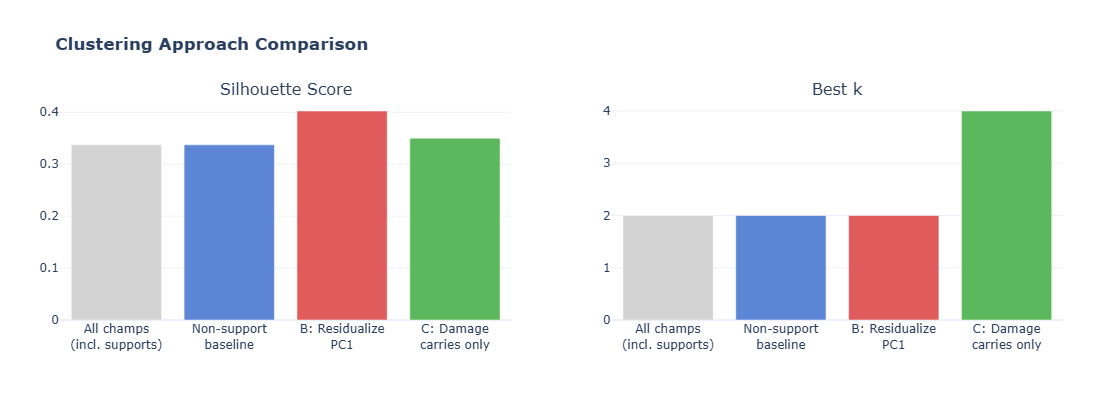


── Verdict ──────────────────────────────────────────────────────────
  Highest silhouette: B: Residualize PC1 (0.4024)
  Most clusters:      C: Damage carries only (k=4)


In [103]:
# ── Alternative Clustering Approaches ─────────────────────────────────────────
# Shows why supports were excluded (baseline all-champs vs non-support),
# then compares strategies *within* the non-support set.

champs_carry = coef_matrix.index.tolist()          # already filtered (non-support)
champs_full  = coef_matrix_full.index.tolist()     # all champions including supports

M_carry = coef_matrix[CLUSTER_FEATURES].values
M_full  = coef_matrix_full[CLUSTER_FEATURES].values

def _run_clustering(M, champs, label):
    scores = {}
    for k in range(2, 9):
        if k >= len(champs): break
        lbls = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(M)
        scores[k] = silhouette_score(M, lbls)
    best_k = max(scores, key=scores.get)
    best_labels = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(M)
    print(f"\n{label}")
    print(f"  n={len(champs)}  best_k={best_k}  silhouette={scores[best_k]:.4f}")
    print(f"  Cluster sizes: {pd.Series(best_labels).value_counts().sort_index().to_dict()}")
    return best_k, scores[best_k], best_labels, scores

# ── All champions (shows why we split out supports) ───────────────────────────
k_full, sil_full, labels_full, _ = _run_clustering(M_full, champs_full, "All champions (includes supports)")

# ── Non-support baseline ──────────────────────────────────────────────────────
k_carry, sil_carry, labels_carry, _ = _run_clustering(M_carry, champs_carry, "Non-support baseline (current pipeline)")

crosstab_carry = pd.crosstab(
    pd.Series([get_class(c) for c in champs_carry], name="class"),
    pd.Series(labels_carry, name="cluster"),
)
print(crosstab_carry.to_string())

# ── B: Residualize PC1 within non-supports ────────────────────────────────────
pca1 = PCA(n_components=1, random_state=RANDOM_STATE)
pc1_proj = pca1.fit_transform(M_carry)
M_resid  = M_carry - pca1.inverse_transform(pc1_proj)
k_resid, sil_resid, labels_resid, _ = _run_clustering(M_resid, champs_carry, "B: Residualize dominant axis (within non-supports)")

crosstab_resid = pd.crosstab(
    pd.Series([get_class(c) for c in champs_carry], name="class"),
    pd.Series(labels_resid, name="cluster"),
)
print(crosstab_resid.to_string())

# ── C: Stratified — damage vs utility within non-supports ─────────────────────
UTILITY_CLASSES = {"Specialist"}   # adjust if needed
champs_dmg = [c for c in champs_carry if get_class(c) not in UTILITY_CLASSES]
champs_utl = [c for c in champs_carry if get_class(c) in UTILITY_CLASSES]
M_dmg = coef_matrix.loc[champs_dmg, CLUSTER_FEATURES].values

k_dmg, sil_dmg, labels_dmg, _ = _run_clustering(M_dmg, champs_dmg, "C: Damage-focused carries only")
sil_c = sil_dmg   # simplified — utility group too small to cluster meaningfully

# ── Summary plot ──────────────────────────────────────────────────────────────
labels_plot  = ["All champs<br>(incl. supports)", "Non-support<br>baseline", "B: Residualize<br>PC1", "C: Damage<br>carries only"]
sils         = [sil_full, sil_carry, sil_resid, sil_c]
ks           = [k_full,   k_carry,   k_resid,   k_dmg]
colors_bar   = ["lightgrey", "#5c85d6", "#e05c5c", "#5cb85c"]

fig = make_subplots(rows=1, cols=2, subplot_titles=["Silhouette Score", "Best k"])
fig.add_trace(go.Bar(x=labels_plot, y=sils, marker_color=colors_bar, showlegend=False,
                     hovertemplate="%{x}<br>Silhouette: %{y:.4f}<extra></extra>"), row=1, col=1)
fig.add_trace(go.Bar(x=labels_plot, y=ks, marker_color=colors_bar, showlegend=False,
                     hovertemplate="%{x}<br>k=%{y}<extra></extra>"), row=1, col=2)
fig.update_layout(
    title=dict(text="<b>Clustering Approach Comparison</b>", font_size=17),
    template=PLOTLY_TEMPLATE, height=400,
    margin=dict(l=60, r=40, t=100, b=80),
)
fig.show()

print("\n── Verdict ──────────────────────────────────────────────────────────")
best_sil = max(zip(labels_plot, sils), key=lambda x: x[1])
most_k   = max(zip(labels_plot, ks),   key=lambda x: x[1])
print(f"  Highest silhouette: {best_sil[0].replace('<br>', ' ')} ({best_sil[1]:.4f})")
print(f"  Most clusters:      {most_k[0].replace('<br>', ' ')} (k={most_k[1]})")


In [107]:
# ── Clustering + k Selection ──────────────────────────────────────────────────
# Features were selected to maximise avg silhouette over k=3..6 (not k=2),
# so clustering is now a separate decision. Inspect the elbow + silhouette
# plot below and set CHOSEN_K. None = auto (silhouette winner across 2..6).

CHOSEN_K = 4   # ← set after inspecting the plot; None = auto

M = coef_matrix[CLUSTER_FEATURES].values
K_RANGE = range(2, 11)

inertias, sil_scores = {}, {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(M)
    inertias[k]   = km.inertia_
    sil_scores[k] = silhouette_score(M, labels)
    print(f"  k={k}  silhouette={sil_scores[k]:.4f}  inertia={inertias[k]:,.0f}")

# ── Elbow + Silhouette plot ────────────────────────────────────────────────────
ks = list(K_RANGE)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ks, y=[sil_scores[k] for k in ks],
    mode="lines+markers", name="Silhouette",
    marker=dict(size=10, color="steelblue"),
    line=dict(color="steelblue", width=2),
    hovertemplate="k=%{x}  silhouette=%{y:.4f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=ks, y=[inertias[k] for k in ks],
    mode="lines+markers", name="Inertia (elbow)",
    marker=dict(size=10, color="tomato"),
    line=dict(color="tomato", width=2, dash="dash"),
    yaxis="y2",
    hovertemplate="k=%{x}  inertia=%{y:,.0f}<extra></extra>",
))

fig.update_layout(
    title=dict(text="<b>k Selection</b> — Silhouette & Elbow (k=2..6)", font_size=17),
    xaxis=dict(title="Number of clusters (k)", tickmode="linear", dtick=1),
    yaxis=dict(title="Silhouette Score", color="steelblue"),
    yaxis2=dict(title="Inertia", overlaying="y", side="right", color="tomato"),
    template=PLOTLY_TEMPLATE, height=380,
    margin=dict(l=70, r=90, t=70, b=60),
    legend=dict(x=0.01, y=0.99),
)
fig.show()

# ── Fit final clustering ───────────────────────────────────────────────────────
best_k_auto = max(sil_scores, key=sil_scores.get)
best_k      = CHOSEN_K if CHOSEN_K is not None else best_k_auto

if CHOSEN_K is not None:
    print(f"\nUsing CHOSEN_K={best_k}  (silhouette winner was k={best_k_auto})")
else:
    print(f"\nAuto-selected k={best_k} (highest silhouette)")

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(M)

coef_matrix["cluster"] = cluster_labels
print("\nChampions per cluster:")
print(coef_matrix["cluster"].value_counts().sort_index().to_string())
print(f"\n→ Change CHOSEN_K to override (currently {CHOSEN_K})")


  k=2  silhouette=0.3373  inertia=54
  k=3  silhouette=0.3151  inertia=41
  k=4  silhouette=0.3350  inertia=30
  k=5  silhouette=0.2959  inertia=27
  k=6  silhouette=0.2702  inertia=25
  k=7  silhouette=0.2510  inertia=23
  k=8  silhouette=0.2477  inertia=21
  k=9  silhouette=0.2214  inertia=20
  k=10  silhouette=0.2392  inertia=18



Using CHOSEN_K=4  (silhouette winner was k=2)

Champions per cluster:
cluster
0    48
1    22
2    36
3    44

→ Change CHOSEN_K to override (currently 4)


In [105]:
# ── Unified Cluster Labels + Color Mapping ────────────────────────────────────
# All champions are in coef_matrix. Build a consistent label/color scheme
# used by all downstream plots.

cluster_label_map = {
    champ: f"Cluster {int(coef_matrix.loc[champ, 'cluster'])}"
    for champ in coef_matrix.index
}

all_labels  = [f"Cluster {i}" for i in range(best_k)]
palette     = px.colors.qualitative.Plotly + px.colors.qualitative.Dark24
label_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}

# Annotated matrix for downstream cells
coef_matrix_combined = coef_matrix.copy()
coef_matrix_combined["cluster_label"] = [cluster_label_map[c] for c in coef_matrix.index]
coef_matrix_combined["group"] = [
    "Support" if get_class(c) in SUPPORT_CLASSES else "Carry"
    for c in coef_matrix.index
]

print("Cluster sizes:")
print(coef_matrix_combined["cluster_label"].value_counts().sort_index().to_string())
print("\nClass breakdown per cluster:")
for lbl in all_labels:
    sub = coef_matrix_combined[coef_matrix_combined["cluster_label"] == lbl]
    classes = pd.Series([get_class(c) for c in sub.index]).value_counts().head(6)
    print(f"  {lbl} (n={len(sub)}): {dict(classes)}")


Cluster sizes:
cluster_label
Cluster 0    16
Cluster 1    45
Cluster 2    17
Cluster 3    22
Cluster 4    17
Cluster 5    33

Class breakdown per cluster:
  Cluster 0 (n=16): {'Vanguard': np.int64(5), 'Catcher': np.int64(2), 'Warden': np.int64(2), 'Specialist': np.int64(2), 'Skirmisher': np.int64(2), 'Marksman': np.int64(1)}
  Cluster 1 (n=45): {'Battlemage': np.int64(7), 'Assassin': np.int64(6), 'Skirmisher': np.int64(6), 'Burst': np.int64(5), 'Diver': np.int64(5), 'Marksman': np.int64(5)}
  Cluster 2 (n=17): {'Marksman': np.int64(8), 'Specialist': np.int64(3), 'Burst': np.int64(3), 'Diver': np.int64(1), 'Assassin': np.int64(1), 'Skirmisher': np.int64(1)}
  Cluster 3 (n=22): {'Marksman': np.int64(10), 'Diver': np.int64(2), 'Battlemage': np.int64(2), 'Artillery': np.int64(2), 'Skirmisher': np.int64(2), 'Specialist': np.int64(1)}
  Cluster 4 (n=17): {'Enchanter': np.int64(4), 'Vanguard': np.int64(3), 'Burst': np.int64(3), 'Assassin': np.int64(3), 'Juggernaut': np.int64(2), 'Specialist':

In [ ]:
# ── Representation Comparison: Coefficient Space vs Win-Delta Space ────────────
from sklearn.metrics import adjusted_rand_score

# ── Build win-delta matrix ─────────────────────────────────────────────────────
champs_in_model = coef_matrix.index.tolist()
delta_rows = {}
for champ in champs_in_model:
    sub    = df[df["championName"] == champ]
    wins   = sub[sub["win"] == True][FEATURES].mean()
    losses = sub[sub["win"] == False][FEATURES].mean()
    delta_rows[champ] = wins - losses

delta_matrix = pd.DataFrame(delta_rows).T.dropna()
common       = [c for c in champs_in_model if c in delta_matrix.index]
delta_matrix = delta_matrix.loc[common]

delta_scaled = pd.DataFrame(
    StandardScaler().fit_transform(delta_matrix[FEATURES]),
    index=common, columns=FEATURES,
)

D_delta = delta_scaled[CLUSTER_FEATURES].values
D_coef  = coef_matrix.loc[common, CLUSTER_FEATURES].values

# ── Cluster both at same k ─────────────────────────────────────────────────────
labels_delta = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(D_delta)
labels_coef  = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(D_coef)

# ── Metrics ────────────────────────────────────────────────────────────────────
sil_coef  = silhouette_score(D_coef,  labels_coef)
sil_delta = silhouette_score(D_delta, labels_delta)
ari       = adjusted_rand_score(labels_coef, labels_delta)

print(f"Silhouette — Coefficient space : {sil_coef:.4f}")
print(f"Silhouette — Win-delta space   : {sil_delta:.4f}")
print(f"Adjusted Rand Index (agreement): {ari:.4f}  (1=identical, 0=random)\n")

# ── Class composition per cluster ──────────────────────────────────────────────
comp_df = pd.DataFrame({
    "champion": common,
    "class":    [get_class(c) for c in common],
    "coef_cl":  labels_coef,
    "delta_cl": labels_delta,
}).set_index("champion")
comp_df["agrees"] = comp_df["coef_cl"] == comp_df["delta_cl"]
print(f"Champion-level agreement: {comp_df['agrees'].mean():.1%}  ({comp_df['agrees'].sum()}/{len(comp_df)})\n")

for rep, col in [("Coefficient", "coef_cl"), ("Win-delta", "delta_cl")]:
    print(f"── {rep} clusters ──")
    for k in range(best_k):
        sub = comp_df[comp_df[col] == k]
        top = pd.Series([get_class(c) for c in sub.index]).value_counts().head(4)
        print(f"  Cluster {k} (n={len(sub)}): {dict(top)}")
    print()

disagree = comp_df[~comp_df["agrees"]].sort_values("class")
if not disagree.empty:
    print(f"Disagreements ({len(disagree)} champions):")
    print(disagree[["class", "coef_cl", "delta_cl"]].to_string())

# ── Scatter plot: per-champion silhouette in each space ────────────────────────
from sklearn.metrics import silhouette_samples

sil_coef_samples  = silhouette_samples(D_coef,  labels_coef)
sil_delta_samples = silhouette_samples(D_delta, labels_delta)

# Color by class (map to integer for colorscale)
all_classes  = sorted(set(get_class(c) for c in common))
class_to_int = {cls: i for i, cls in enumerate(all_classes)}
color_ints   = [class_to_int[get_class(c)] for c in common]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sil_coef_samples, y=sil_delta_samples,
    mode="markers",
    marker=dict(size=7, opacity=0.7,
                color=color_ints, colorscale="Turbo", showscale=True,
                colorbar=dict(
                    title="Class",
                    tickvals=list(class_to_int.values()),
                    ticktext=list(class_to_int.keys()),
                    thickness=14,
                )),
    text=common,
    customdata=[get_class(c) for c in common],
    hovertemplate="<b>%{text}</b> (%{customdata})<br>Coef sil: %{x:.3f}<br>Delta sil: %{y:.3f}<extra></extra>",
))
fig.add_shape(type="line", x0=-1, y0=-1, x1=1, y1=1,
              line=dict(dash="dot", color="grey", width=1))
fig.add_annotation(x=0.02, y=0.97, xref="paper", yref="paper",
                   text=f"ARI={ari:.3f}  |  sil coef={sil_coef:.3f}  sil delta={sil_delta:.3f}",
                   showarrow=False, font=dict(size=12), bgcolor="white")
fig.update_layout(
    title=dict(text="<b>Representation Comparison</b> — per-champion silhouette: coef vs win-delta<br>"
                    "<sup>Above diagonal = better separated in win-delta space</sup>", font_size=15),
    xaxis=dict(title="Silhouette (coefficient space)", range=[-1, 1]),
    yaxis=dict(title="Silhouette (win-delta space)",   range=[-1, 1]),
    template=PLOTLY_TEMPLATE, height=520,
    margin=dict(l=70, r=140, t=90, b=70),
)
fig.show()


In [ ]:
# ── Silhouette Plot ───────────────────────────────────────────────────────────

from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(M, cluster_labels)
mean_sil = silhouette_scores[best_k]

sil_df = (
    pd.DataFrame({
        "champion":   coef_matrix.index.tolist(),
        "cluster":    cluster_labels,
        "silhouette": sil_samples,
    })
    .sort_values(["cluster", "silhouette"], ascending=[True, False])
)

colors = px.colors.qualitative.Plotly
fig = go.Figure()
for cid in sorted(sil_df["cluster"].unique()):
    sub = sil_df[sil_df["cluster"] == cid]
    fig.add_trace(go.Bar(
        y=sub["champion"],
        x=sub["silhouette"],
        orientation="h",
        name=f"Cluster {cid}",
        marker_color=colors[cid % len(colors)],
        hovertemplate="%{y}: %{x:.3f}<extra></extra>",
    ))

fig.add_vline(x=mean_sil, line_dash="dash", line_color="black",
              annotation_text=f"mean = {mean_sil:.3f}",
              annotation_position="top right")
fig.add_vline(x=0, line_width=1, line_color="gray")

fig.update_layout(
    title=dict(text="<b>Silhouette Plot</b> — Per-Champion Cluster Confidence", font_size=17),
    xaxis=dict(title="Silhouette Coefficient", range=[-1, 1]),
    yaxis=dict(title="Champion", autorange="reversed", tickfont=dict(size=9)),
    template=PLOTLY_TEMPLATE,
    barmode="overlay",
    height=max(500, len(sil_df) * 16),
    margin=dict(l=130, r=80, t=70, b=50),
    legend=dict(x=1.01, y=1),
)
fig.show()


In [ ]:
# ── 7. Compare to Champion Classes ───────────────────────────────────────────
# Map each champion to its Riot subclass (Juggernaut, Enchanter, etc.)
# and join with cluster assignments.

class_map = pd.Series(
    {champ: get_class(champ) for champ in coef_matrix.index},
    name="champion_class"
)

cluster_class = coef_matrix[["cluster"]].join(class_map)
cluster_class["champion_class"] = cluster_class["champion_class"].fillna("Unknown")

# How many champions per class were mapped vs unknown
unknown = cluster_class[cluster_class["champion_class"] == "Unknown"].index.tolist()
if unknown:
    print(f"Unknown class ({len(unknown)}): {unknown}")

crosstab = pd.crosstab(
    cluster_class["cluster"],
    cluster_class["champion_class"],
    normalize="index"
).round(3)

# Reindex columns to CLASS_ORDER (only those present)
present_classes = [c for c in CLASS_ORDER if c in crosstab.columns]
crosstab = crosstab[present_classes]

print("\nCluster × Champion Class proportions:")
print(crosstab.to_string())


In [ ]:
# ── 8. Per-Champion Win Profile — Bar Chart ──────────────────────────────────
# Positive coefficient = this stat is associated with winning on this champion.
# Negative = winning champions tend to have LOW values of this stat.

_global_min = coef_matrix[FEATURES].min()
_global_max = coef_matrix[FEATURES].max()
_global_range = (_global_max - _global_min).replace(0, 1e-9)

def plot_champion_bar(champ):
    if champ not in coef_map:
        print(f"{champ} not found.")
        return
    coefs = coef_map[champ].sort_values()
    bar_colors = ["#e05c5c" if v > 0 else "#5c85d6" for v in coefs]
    fig = go.Figure(go.Bar(
        x=coefs.values, y=coefs.index, orientation="h",
        marker_color=bar_colors,
        hovertemplate="%{y}: %{x:.3f}<extra></extra>",
    ))
    fig.add_vline(x=0, line_width=1, line_color="black")
    fig.update_layout(
        title=dict(text=f"<b>{champ}</b> — Coefficient Bar Chart", font_size=17),
        xaxis_title="Standardized Coefficient",
        template=PLOTLY_TEMPLATE, height=460,
        margin=dict(l=170, r=40, t=60, b=50),
    )
    fig.show()

# Change champion name to inspect any champion in the dataset
INSPECT = "Jinx"
plot_champion_bar(INSPECT)


In [ ]:
# ── UMAP Scatter — all champions ──────────────────────────────────────────────
import umap  # lazy import: umap-learn triggers numba JIT on load

M_all      = coef_matrix[CLUSTER_FEATURES].values
all_champs = coef_matrix.index.tolist()

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
coords  = reducer.fit_transform(M_all)

umap_df = pd.DataFrame({
    "UMAP1":         coords[:, 0],
    "UMAP2":         coords[:, 1],
    "cluster_label": [cluster_label_map[c] for c in all_champs],
    "group":         ["Support" if get_class(c) in SUPPORT_CLASSES else "Carry"
                      for c in all_champs],
    "champion":      all_champs,
    "class":         [get_class(c) for c in all_champs],
    "n_games":       [int(metrics_map[c]["n_games"]) for c in all_champs],
    "auc":           [round(metrics_map[c]["auc"], 3) for c in all_champs],
})

fig = go.Figure()
for lbl in all_labels:
    sub = umap_df[umap_df["cluster_label"] == lbl]
    # Supports shown as diamonds, carries as circles — within the same cluster color
    for group, symbol, show_legend in [("Carry", "circle", True), ("Support", "diamond", False)]:
        grp = sub[sub["group"] == group]
        if grp.empty:
            continue
        fig.add_trace(go.Scatter(
            x=grp["UMAP1"], y=grp["UMAP2"],
            mode="markers+text",
            name=lbl,
            legendgroup=lbl,
            showlegend=show_legend,
            marker=dict(
                color=label_color[lbl], size=9, symbol=symbol,
                line=dict(width=0.5, color="white"),
            ),
            text=grp["champion"],
            textposition="top center",
            textfont=dict(size=8),
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Class: %{customdata[0]}<br>"
                "Cluster: " + lbl + "<br>"
                "Games: %{customdata[1]}<br>"
                "AUC: %{customdata[2]}<extra></extra>"
            ),
            customdata=grp[["class", "n_games", "auc"]].values,
        ))

fig.update_layout(
    title=dict(text="<b>UMAP — All Champions</b> (◆ = support class, ● = carry class)", font_size=17),
    xaxis_title="UMAP1", yaxis_title="UMAP2",
    legend=dict(title="Cluster", x=1.01, y=1),
    template=PLOTLY_TEMPLATE, height=700,
    margin=dict(l=50, r=160, t=80, b=50),
)
fig.show()


In [ ]:
# ── 11. Clustered Heatmap ─────────────────────────────────────────────────────

feat_only = coef_matrix[FEATURES].copy()

# Row ordering: AgglomerativeClustering (Ward), then sort within each cluster by PC1
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(feat_only.values)

row_order = []
for cid in range(best_k):
    idxs = np.where(agg_labels == cid)[0]
    sub = feat_only.values[idxs]
    if len(idxs) > 1:
        pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(sub)[:, 0]
        row_order.extend(idxs[np.argsort(pc1)])
    else:
        row_order.extend(idxs)

col_order = feat_only.abs().mean().sort_values(ascending=False).index.tolist()
ordered = feat_only.iloc[row_order][col_order]
ordered_champs = ordered.index.tolist()

# Single boundary line position (AgglomerativeClustering order is clean)
agg_series = pd.Series(agg_labels, index=feat_only.index)
ordered_agg = agg_series.iloc[row_order].values
boundaries = [i for i in range(1, len(row_order)) if ordered_agg[i] != ordered_agg[i - 1]]

# KMeans cluster per champion for annotations
kmeans_ordered = coef_matrix.loc[ordered_champs, "cluster"].values
cluster_colors = px.colors.qualitative.Plotly

fig = go.Figure(go.Heatmap(
    z=ordered.values,
    x=col_order,
    y=ordered_champs,
    colorscale="RdBu_r",
    zmid=0,
    colorbar=dict(title="Coefficient", thickness=14),
    hovertemplate="Champion: %{y}<br>Feature: %{x}<br>Coefficient: %{z:.3f}<extra></extra>",
))

# Cluster boundary lines (one per agg cluster boundary — clean, not random)
for b in boundaries:
    fig.add_hline(y=b - 0.5, line_width=1.5, line_dash="dash", line_color="rgba(0,0,0,0.5)")

# Cluster label annotations on the left
for cid in range(best_k):
    rows_in_cluster = [i for i, l in enumerate(ordered_agg) if l == cid]
    if not rows_in_cluster:
        continue
    mid = rows_in_cluster[len(rows_in_cluster) // 2]
    fig.add_annotation(
        x=-0.01, xref="paper",
        y=ordered_champs[mid], yref="y",
        text=f"<b>C{cid}</b>",
        showarrow=False,
        font=dict(size=11, color=cluster_colors[cid % len(cluster_colors)]),
        xanchor="right",
    )

fig.update_layout(
    title=dict(text="<b>Clustered Heatmap</b> — Champion Win Profiles (Ward linkage ordering)", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis=dict(title="Champion", autorange="reversed", tickfont=dict(size=10)),
    template=PLOTLY_TEMPLATE,
    height=max(500, len(ordered) * 16),
    margin=dict(l=140, r=60, t=70, b=100),
)
fig.show()

# Export for downstream cells
sorted_champs = ordered_champs
feat_order = col_order


In [ ]:
# ── Champion Class vs Cluster ──────────────────────────────────────────────────

class_cluster_df = pd.DataFrame({
    "champion":      coef_matrix.index,
    "class":         [get_class(c) for c in coef_matrix.index],
    "cluster_label": [cluster_label_map[c] for c in coef_matrix.index],
})

present_classes = [c for c in CLASS_ORDER if c in class_cluster_df["class"].values]

crosstab_unified = pd.crosstab(
    class_cluster_df["class"],
    class_cluster_df["cluster_label"],
    normalize="index",
).reindex(index=present_classes).fillna(0)
crosstab_unified = crosstab_unified[[c for c in all_labels if c in crosstab_unified.columns]]

fig = go.Figure()
for lbl in all_labels:
    if lbl not in crosstab_unified.columns:
        continue
    fig.add_trace(go.Bar(
        name=lbl,
        x=present_classes,
        y=crosstab_unified[lbl].values,
        marker_color=label_color[lbl],
        hovertemplate=f"<b>{lbl}</b><br>%{{x}}: %{{y:.1%}}<extra></extra>",
    ))

fig.update_layout(
    barmode="stack",
    title=dict(text="<b>Champion Class vs Cluster</b>", font_size=17),
    xaxis=dict(title="Champion Class", tickangle=-30),
    yaxis=dict(title="Proportion of Class", tickformat=".0%"),
    legend=dict(title="Cluster", x=1.01, y=1),
    template=PLOTLY_TEMPLATE, height=480,
    margin=dict(l=60, r=160, t=70, b=80),
)
fig.show()


In [ ]:
# ── Cluster Centroid Profiles — Bar Chart ─────────────────────────────────────
# Average coefficient per feature for each cluster (using CLUSTER_FEATURES only).

centroid_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=CLUSTER_FEATURES,
    index=[f"Cluster {i}" for i in range(best_k)],
)

colors = px.colors.qualitative.Plotly
feat_order_cent = centroid_df.abs().mean().sort_values(ascending=False).index.tolist()

fig = go.Figure()
for i, (name, row) in enumerate(centroid_df[feat_order_cent].iterrows()):
    fig.add_trace(go.Bar(
        name=name,
        x=feat_order_cent,
        y=row.values,
        marker_color=colors[i % len(colors)],
        hovertemplate=f"<b>{name}</b><br>%{{x}}: %{{y:.3f}}<extra></extra>",
    ))

fig.add_hline(y=0, line_width=1, line_color="black")
fig.update_layout(
    barmode="group",
    title=dict(text="<b>Cluster Centroid Profiles</b> — Average Coefficient per Cluster", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis_title="Mean Coefficient",
    legend=dict(title="Cluster", x=1.01, y=1),
    template=PLOTLY_TEMPLATE,
    height=460,
    margin=dict(l=60, r=120, t=70, b=100),
)
fig.show()


In [ ]:
# ── Top-N Features Per Champion ───────────────────────────────────────────────
# For each champion: their top N features by absolute coefficient value.
# Positive = this stat drives wins. Negative = winning means having LOW values.

TOP_N = 3

feat_only = coef_matrix[FEATURES]
rows = []
for champ in feat_only.index:
    coefs = feat_only.loc[champ].abs().sort_values(ascending=False)
    for rank, feat in enumerate(coefs.index[:TOP_N], 1):
        raw = feat_only.loc[champ, feat]
        rows.append({
            "champion":  champ,
            "cluster":   int(coef_matrix.loc[champ, "cluster"]),
            "class":     get_class(champ),
            f"rank_{rank}_feature": feat,
            f"rank_{rank}_coef":    round(raw, 3),
        })

# Pivot so each champion is one row
top_df = (
    pd.DataFrame(rows)
    .groupby(["champion", "cluster", "class"])
    .first()
    .reset_index()
)

# Interactive plotly table
col_labels = ["Champion", "Cluster", "Class"] + [
    f for rank in range(1, TOP_N + 1)
    for f in [f"#{rank} Feature", f"#{rank} Coef"]
]
col_keys = ["champion", "cluster", "class"] + [
    f for rank in range(1, TOP_N + 1)
    for f in [f"rank_{rank}_feature", f"rank_{rank}_coef"]
]

cell_colors = []
cluster_palette = px.colors.qualitative.Pastel
for key in col_keys:
    if key == "cluster":
        cell_colors.append([cluster_palette[int(v) % len(cluster_palette)] for v in top_df[key]])
    elif "coef" in key:
        cell_colors.append([
            "rgba(224,92,92,0.25)" if v > 0 else "rgba(92,133,214,0.25)"
            for v in top_df[key]
        ])
    else:
        cell_colors.append(["white"] * len(top_df))

fig = go.Figure(go.Table(
    header=dict(
        values=[f"<b>{c}</b>" for c in col_labels],
        fill_color="#f0f0f0",
        align="left",
        font=dict(size=12),
        line_color="lightgrey",
    ),
    cells=dict(
        values=[top_df[k].tolist() for k in col_keys],
        fill_color=cell_colors,
        align="left",
        font=dict(size=11),
        line_color="lightgrey",
        height=24,
    ),
))
fig.update_layout(
    title=dict(text=f"<b>Top {TOP_N} Win-Driving Features per Champion</b>", font_size=17),
    template=PLOTLY_TEMPLATE,
    height=max(400, len(top_df) * 26 + 80),
    margin=dict(l=20, r=20, t=60, b=20),
)
fig.show()


In [ ]:
# ── Champion Uniqueness — Z-Score Heatmap ────────────────────────────────────
# Z-score of each champion's coefficient relative to all other champions,
# per feature. High absolute z = this champion is an outlier on that stat.

feat_only = coef_matrix[FEATURES].copy()
z_scores = (feat_only - feat_only.mean()) / feat_only.std().replace(0, 1e-9)
z_sorted = z_scores.loc[sorted_champs, feat_order]

# Cluster assignments in the same row order as the clustered heatmap
agg_z = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels_z = agg_z.fit_predict(feat_only.values)
agg_series_z = pd.Series(agg_labels_z, index=feat_only.index)
ordered_agg_z = agg_series_z.loc[sorted_champs].values
boundaries_z = [i for i in range(1, len(sorted_champs)) if ordered_agg_z[i] != ordered_agg_z[i - 1]]

cluster_colors = px.colors.qualitative.Plotly

fig = go.Figure(go.Heatmap(
    z=z_sorted.values,
    x=feat_order,
    y=sorted_champs,
    colorscale="RdBu_r",
    zmid=0,
    colorbar=dict(title="Z-Score", thickness=14),
    hovertemplate="<b>%{y}</b> — %{x}<br>Z-score: %{z:.2f}<extra></extra>",
))

for b in boundaries_z:
    fig.add_hline(y=b - 0.5, line_width=1.5, line_dash="dash", line_color="rgba(0,0,0,0.5)")

for cid in range(best_k):
    rows_in_cluster = [i for i, l in enumerate(ordered_agg_z) if l == cid]
    if not rows_in_cluster:
        continue
    mid = rows_in_cluster[len(rows_in_cluster) // 2]
    fig.add_annotation(
        x=-0.01, xref="paper",
        y=sorted_champs[mid], yref="y",
        text=f"<b>C{cid}</b>",
        showarrow=False,
        font=dict(size=11, color=cluster_colors[cid % len(cluster_colors)]),
        xanchor="right",
    )

fig.update_layout(
    title=dict(text="<b>Champion Uniqueness — Z-Score Heatmap</b>", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis=dict(title="Champion", autorange="reversed", tickfont=dict(size=10)),
    template=PLOTLY_TEMPLATE,
    height=max(500, len(sorted_champs) * 16),
    margin=dict(l=140, r=60, t=80, b=100),
)
fig.show()


In [ ]:
# ── Feature Leaders Table ─────────────────────────────────────────────────────
# For each feature: which champion has the highest and lowest z-score.

leader_rows = []
for feat in FEATURES:
    col = z_scores[feat]
    top_champ    = col.idxmax()
    bottom_champ = col.idxmin()
    leader_rows.append({
        "feature":       feat,
        "highest_champ": top_champ,
        "highest_z":     round(col[top_champ], 2),
        "lowest_champ":  bottom_champ,
        "lowest_z":      round(col[bottom_champ], 2),
    })

leaders_df = pd.DataFrame(leader_rows).sort_values("feature")

fig = go.Figure(go.Table(
    header=dict(
        values=["<b>Feature</b>",
                "<b>Most correlated</b>", "<b>Z</b>",
                "<b>Least correlated</b>", "<b>Z</b>"],
        fill_color="#f0f0f0",
        align="left",
        font=dict(size=12),
        line_color="lightgrey",
    ),
    cells=dict(
        values=[
            leaders_df["feature"].tolist(),
            leaders_df["highest_champ"].tolist(),
            leaders_df["highest_z"].tolist(),
            leaders_df["lowest_champ"].tolist(),
            leaders_df["lowest_z"].tolist(),
        ],
        fill_color=[
            ["white"] * len(leaders_df),
            ["rgba(224,92,92,0.2)"] * len(leaders_df),
            ["rgba(224,92,92,0.2)"] * len(leaders_df),
            ["rgba(92,133,214,0.2)"] * len(leaders_df),
            ["rgba(92,133,214,0.2)"] * len(leaders_df),
        ],
        align="left",
        font=dict(size=11),
        line_color="lightgrey",
        height=26,
    ),
))
fig.update_layout(
    title=dict(text="<b>Feature Leaders</b> — Most & Least Correlated Champion per Stat (by Z-score)", font_size=17),
    template=PLOTLY_TEMPLATE,
    height=max(400, len(leaders_df) * 28 + 80),
    margin=dict(l=20, r=20, t=60, b=20),
)
fig.show()


In [ ]:
# ── Case Study — Multi-Champion Comparison ────────────────────────────────────
CASE_STUDY = ["Jinx", "Thresh", "Zed"]

in_model = [c for c in CASE_STUDY if c in coef_map]
missing  = [c for c in CASE_STUDY if c not in coef_map]
if missing:
    print(f"Not found in model (too few games?): {missing}")

case_colors = px.colors.qualitative.Plotly[:len(in_model)]

# ── 1. Coefficient bar chart ───────────────────────────────────────────────────
fig = go.Figure()
for i, champ in enumerate(in_model):
    coefs = coef_map[champ].reindex(FEATURES)
    fig.add_trace(go.Bar(
        name=champ, x=FEATURES, y=coefs.values,
        marker_color=case_colors[i],
        hovertemplate=f"<b>{champ}</b><br>%{{x}}: %{{y:.3f}}<extra></extra>",
    ))
fig.add_hline(y=0, line_width=1, line_color="black")
fig.update_layout(
    barmode="group",
    title=dict(text=f"<b>Coefficient Comparison</b> — {', '.join(in_model)}", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis_title="Standardized Coefficient",
    legend=dict(title="Champion"),
    template=PLOTLY_TEMPLATE, height=460,
    margin=dict(l=60, r=120, t=70, b=120),
)
fig.show()

# ── 2. Z-score comparison ──────────────────────────────────────────────────────
z_case = z_scores.reindex([c for c in in_model if c in z_scores.index])

fig2 = go.Figure()
for i, champ in enumerate(z_case.index):
    fig2.add_trace(go.Bar(
        name=champ, x=FEATURES,
        y=z_case.loc[champ].reindex(FEATURES).values,
        marker_color=case_colors[in_model.index(champ)],
        hovertemplate=f"<b>{champ}</b><br>%{{x}}: %{{y:.2f}}σ<extra></extra>",
    ))
fig2.add_hline(y=0, line_width=1, line_color="black")
fig2.add_hline(y=1,  line_dash="dot", line_color="grey",
               annotation_text="+1σ", annotation_position="right")
fig2.add_hline(y=-1, line_dash="dot", line_color="grey",
               annotation_text="−1σ", annotation_position="right")
fig2.update_layout(
    barmode="group",
    title=dict(text="<b>Z-Score Comparison</b>", font_size=17),
    xaxis=dict(tickangle=-35, title="Feature"),
    yaxis_title="Z-Score (σ from mean)",
    legend=dict(title="Champion"),
    template=PLOTLY_TEMPLATE, height=460,
    margin=dict(l=60, r=120, t=70, b=120),
)
fig2.show()

# ── 3. UMAP positioning ────────────────────────────────────────────────────────
if in_model:
    is_case = umap_df["champion"].isin(in_model)
    fig3 = go.Figure()
    bg = umap_df[~is_case]
    fig3.add_trace(go.Scatter(
        x=bg["UMAP1"], y=bg["UMAP2"], mode="markers",
        marker=dict(color="lightgrey", size=6, line=dict(width=0.5, color="white")),
        text=bg["champion"],
        hovertemplate="<b>%{text}</b><br>UMAP1: %{x:.2f}, UMAP2: %{y:.2f}<extra></extra>",
        name="Other",
    ))
    for i, champ in enumerate(in_model):
        row = umap_df[umap_df["champion"] == champ]
        if row.empty:
            continue
        col = case_colors[i]
        fig3.add_trace(go.Scatter(
            x=row["UMAP1"], y=row["UMAP2"], mode="markers+text",
            marker=dict(color=col, size=14, line=dict(width=1.5, color="white")),
            text=[champ], textposition="top center",
            textfont=dict(size=11, color=col),
            hovertemplate=(
                f"<b>{champ}</b><br>Class: {get_class(champ)}<br>"
                f"Cluster: {row['cluster_label'].values[0]}<extra></extra>"
            ),
            name=champ,
        ))
    fig3.update_layout(
        title=dict(text="<b>UMAP — Case Study Positioning</b>", font_size=17),
        xaxis_title="UMAP1", yaxis_title="UMAP2",
        template=PLOTLY_TEMPLATE, height=600,
        margin=dict(l=50, r=50, t=80, b=50),
        legend=dict(x=1.01, y=1),
    )
    fig3.show()

# ── 4. Summary table ──────────────────────────────────────────────────────────
summary_rows = []
for i, champ in enumerate(in_model):
    if champ not in coef_matrix.index:
        continue
    coefs = coef_map[champ]
    top3  = coefs.abs().sort_values(ascending=False).head(3)
    summary_rows.append({
        "Champion":   champ,
        "Class":      get_class(champ),
        "Cluster":    cluster_label_map.get(champ, "—"),
        "Games":      int(metrics_map[champ]["n_games"]),
        "AUC":        round(metrics_map[champ]["auc"], 3),
        "#1 Feature": f"{top3.index[0]} ({coefs[top3.index[0]]:+.2f})",
        "#2 Feature": f"{top3.index[1]} ({coefs[top3.index[1]]:+.2f})",
        "#3 Feature": f"{top3.index[2]} ({coefs[top3.index[2]]:+.2f})",
    })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    col_keys = list(summary_df.columns)
    fig4 = go.Figure(go.Table(
        header=dict(values=[f"<b>{c}</b>" for c in col_keys],
                    fill_color="#f0f0f0", align="left",
                    font=dict(size=12), line_color="lightgrey"),
        cells=dict(
            values=[summary_df[k].tolist() for k in col_keys],
            fill_color=[
                [case_colors[i % len(case_colors)] for i in range(len(summary_df))]
                if k == "Champion" else ["white"] * len(summary_df)
                for k in col_keys
            ],
            align="left", font=dict(size=11),
            line_color="lightgrey", height=28,
        ),
    ))
    fig4.update_layout(
        title=dict(text="<b>Case Study Summary</b>", font_size=17),
        template=PLOTLY_TEMPLATE,
        height=max(200, len(summary_df) * 40 + 100),
        margin=dict(l=20, r=20, t=60, b=20),
    )
    fig4.show()
